In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
df_RUL4 = pd.read_csv('../../CMAPSSData/RUL_FD004.csv')
df_TEST4 = pd.read_csv('../../CMAPSSData/test_FD004.csv')
df = pd.read_csv('../../CMAPSSData/train_FD004.csv')

In [8]:
df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


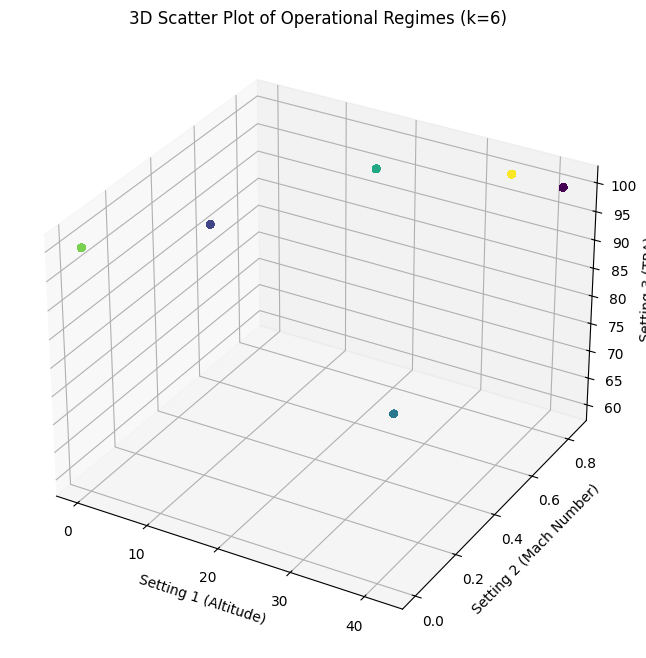

In [9]:
# 1. 데이터 로드 (컬럼명 지정)
# df = pd.read_csv('train_FD002.txt', sep='\s+', header=None, ...)
settings = df[['setting_1', 'setting_2', 'setting_3']]

# 2. 데이터 정규화 (스케일링)
scaler = StandardScaler()
settings_scaled = scaler.fit_transform(settings)

# 3. K-Means 클러스터링 (k=6)
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(settings_scaled)

# 4. 3D 산점도 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['setting_1'], df['setting_2'], df['setting_3'], 
                c=df['Cluster'], cmap='viridis', marker='o', alpha=0.5)

ax.set_xlabel('Setting 1 (Altitude)')
ax.set_ylabel('Setting 2 (Mach Number)')
ax.set_zlabel('Setting 3 (TRA)')
plt.title('3D Scatter Plot of Operational Regimes (k=6)')
plt.show()

In [10]:
# 전체 데이터의 Sensor 2 표준편차
raw_std = df['setting_1'].std()

# 군집별 Sensor 2 표준편차의 평균
cluster_std = df.groupby('Cluster')['setting_1'].std().mean()

print(f"클러스터링 전 전체 표준편차: {raw_std:.4f}")
print(f"클러스터링 후 군집 내 평균 표준편차: {cluster_std:.4f}")
print(f"노이즈 감소율: {(raw_std - cluster_std) / raw_std * 100:.2f}%")

클러스터링 전 전체 표준편차: 14.7807
클러스터링 후 군집 내 평균 표준편차: 0.0026
노이즈 감소율: 99.98%


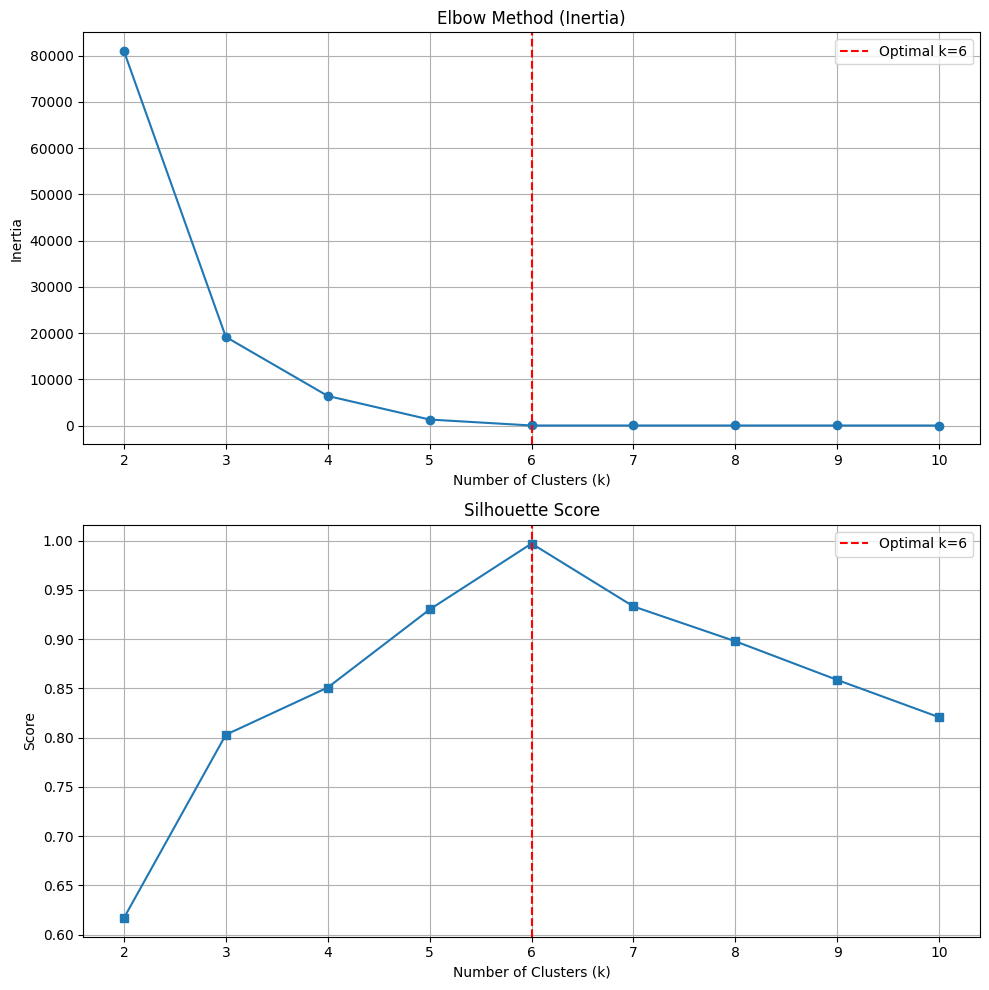

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. 데이터 로드 및 정규화 (이전 단계와 동일)
# df = pd.read_csv('train_FD002.txt', sep='\s+', header=None, ...)
settings = df[['setting_1', 'setting_2', 'setting_3']]
scaler = StandardScaler()
settings_scaled = scaler.fit_transform(settings)

# 2. 지표 저장을 위한 리스트 초기화
k_values = range(2, 11)
inertias = []
silhouette_scores = []

# 3. K 변화에 따른 모델 학습 및 지표 계산
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(settings_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(settings_scaled, labels))

# 4. 시각화 (Elbow Method & Silhouette Score)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# 엘보우 방법 그래프
ax1.plot(k_values, inertias, marker='o', linestyle='-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.axvline(x=6, color='r', linestyle='--', label='Optimal k=6')
ax1.legend()
ax1.grid(True)

# 실루엣 점수 그래프
ax2.plot(k_values, silhouette_scores, marker='s', linestyle='-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Score')
ax2.axvline(x=6, color='r', linestyle='--', label='Optimal k=6')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# 군집 번호를 알파벳 라벨로 매핑 (0->A, 1->B, ... 5->F)
cluster_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F'}
df['Cluster_Label'] = df['Cluster'].map(cluster_map)

# 변환 결과 확인
print(df[['Cluster', 'Cluster_Label']].head())

   Cluster Cluster_Label
0        0             A
1        3             D
2        0             A
3        0             A
4        2             C


|군집 번호 (예시)|고도 (Setting 1)|속도 (Setting 2)|스로틀 (Setting 3)|	예상 운행 조건|
- A	42 ft	0.84 mach	100	최대 고도 고속 운행
- B	0.001 ft	0.0005 mach	100	지상 대기 및 이륙
- C	20 ft	0.7 mach	100	중고도 비행
- D	25 ft	0.6 mach	60	중고도 상승/하강
- E	10 ft	0.25 mach	100	저고도 하강/접근
- F	35 ft	0.84 mach	100	일반 순항

In [13]:
# 군집별 설정값의 평균 확인
regime_summary = df.groupby('Cluster_Label')[['setting_1', 'setting_2', 'setting_3']].mean()

# 결과 정렬 (고도 기준)
print(regime_summary.sort_values(by='setting_1'))

               setting_1  setting_2  setting_3
Cluster_Label                                 
E               0.001508   0.000495      100.0
B              10.002990   0.250503      100.0
D              20.002974   0.700505      100.0
C              25.003053   0.620504       60.0
F              35.003029   0.840506      100.0
A              42.002987   0.840495      100.0


C:\Users\yesyo\AppData\Local\Temp\ipykernel_34672\2551421707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df, ax=axes[i],
C:\Users\yesyo\AppData\Local\Temp\ipykernel_34672\2551421707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df, ax=axes[i],
C:\Users\yesyo\AppData\Local\Temp\ipykernel_34672\2551421707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df, ax=axes[i],
C:\Users\yesyo\AppData\Local\Temp\ipykernel_34672\2551421707.py:

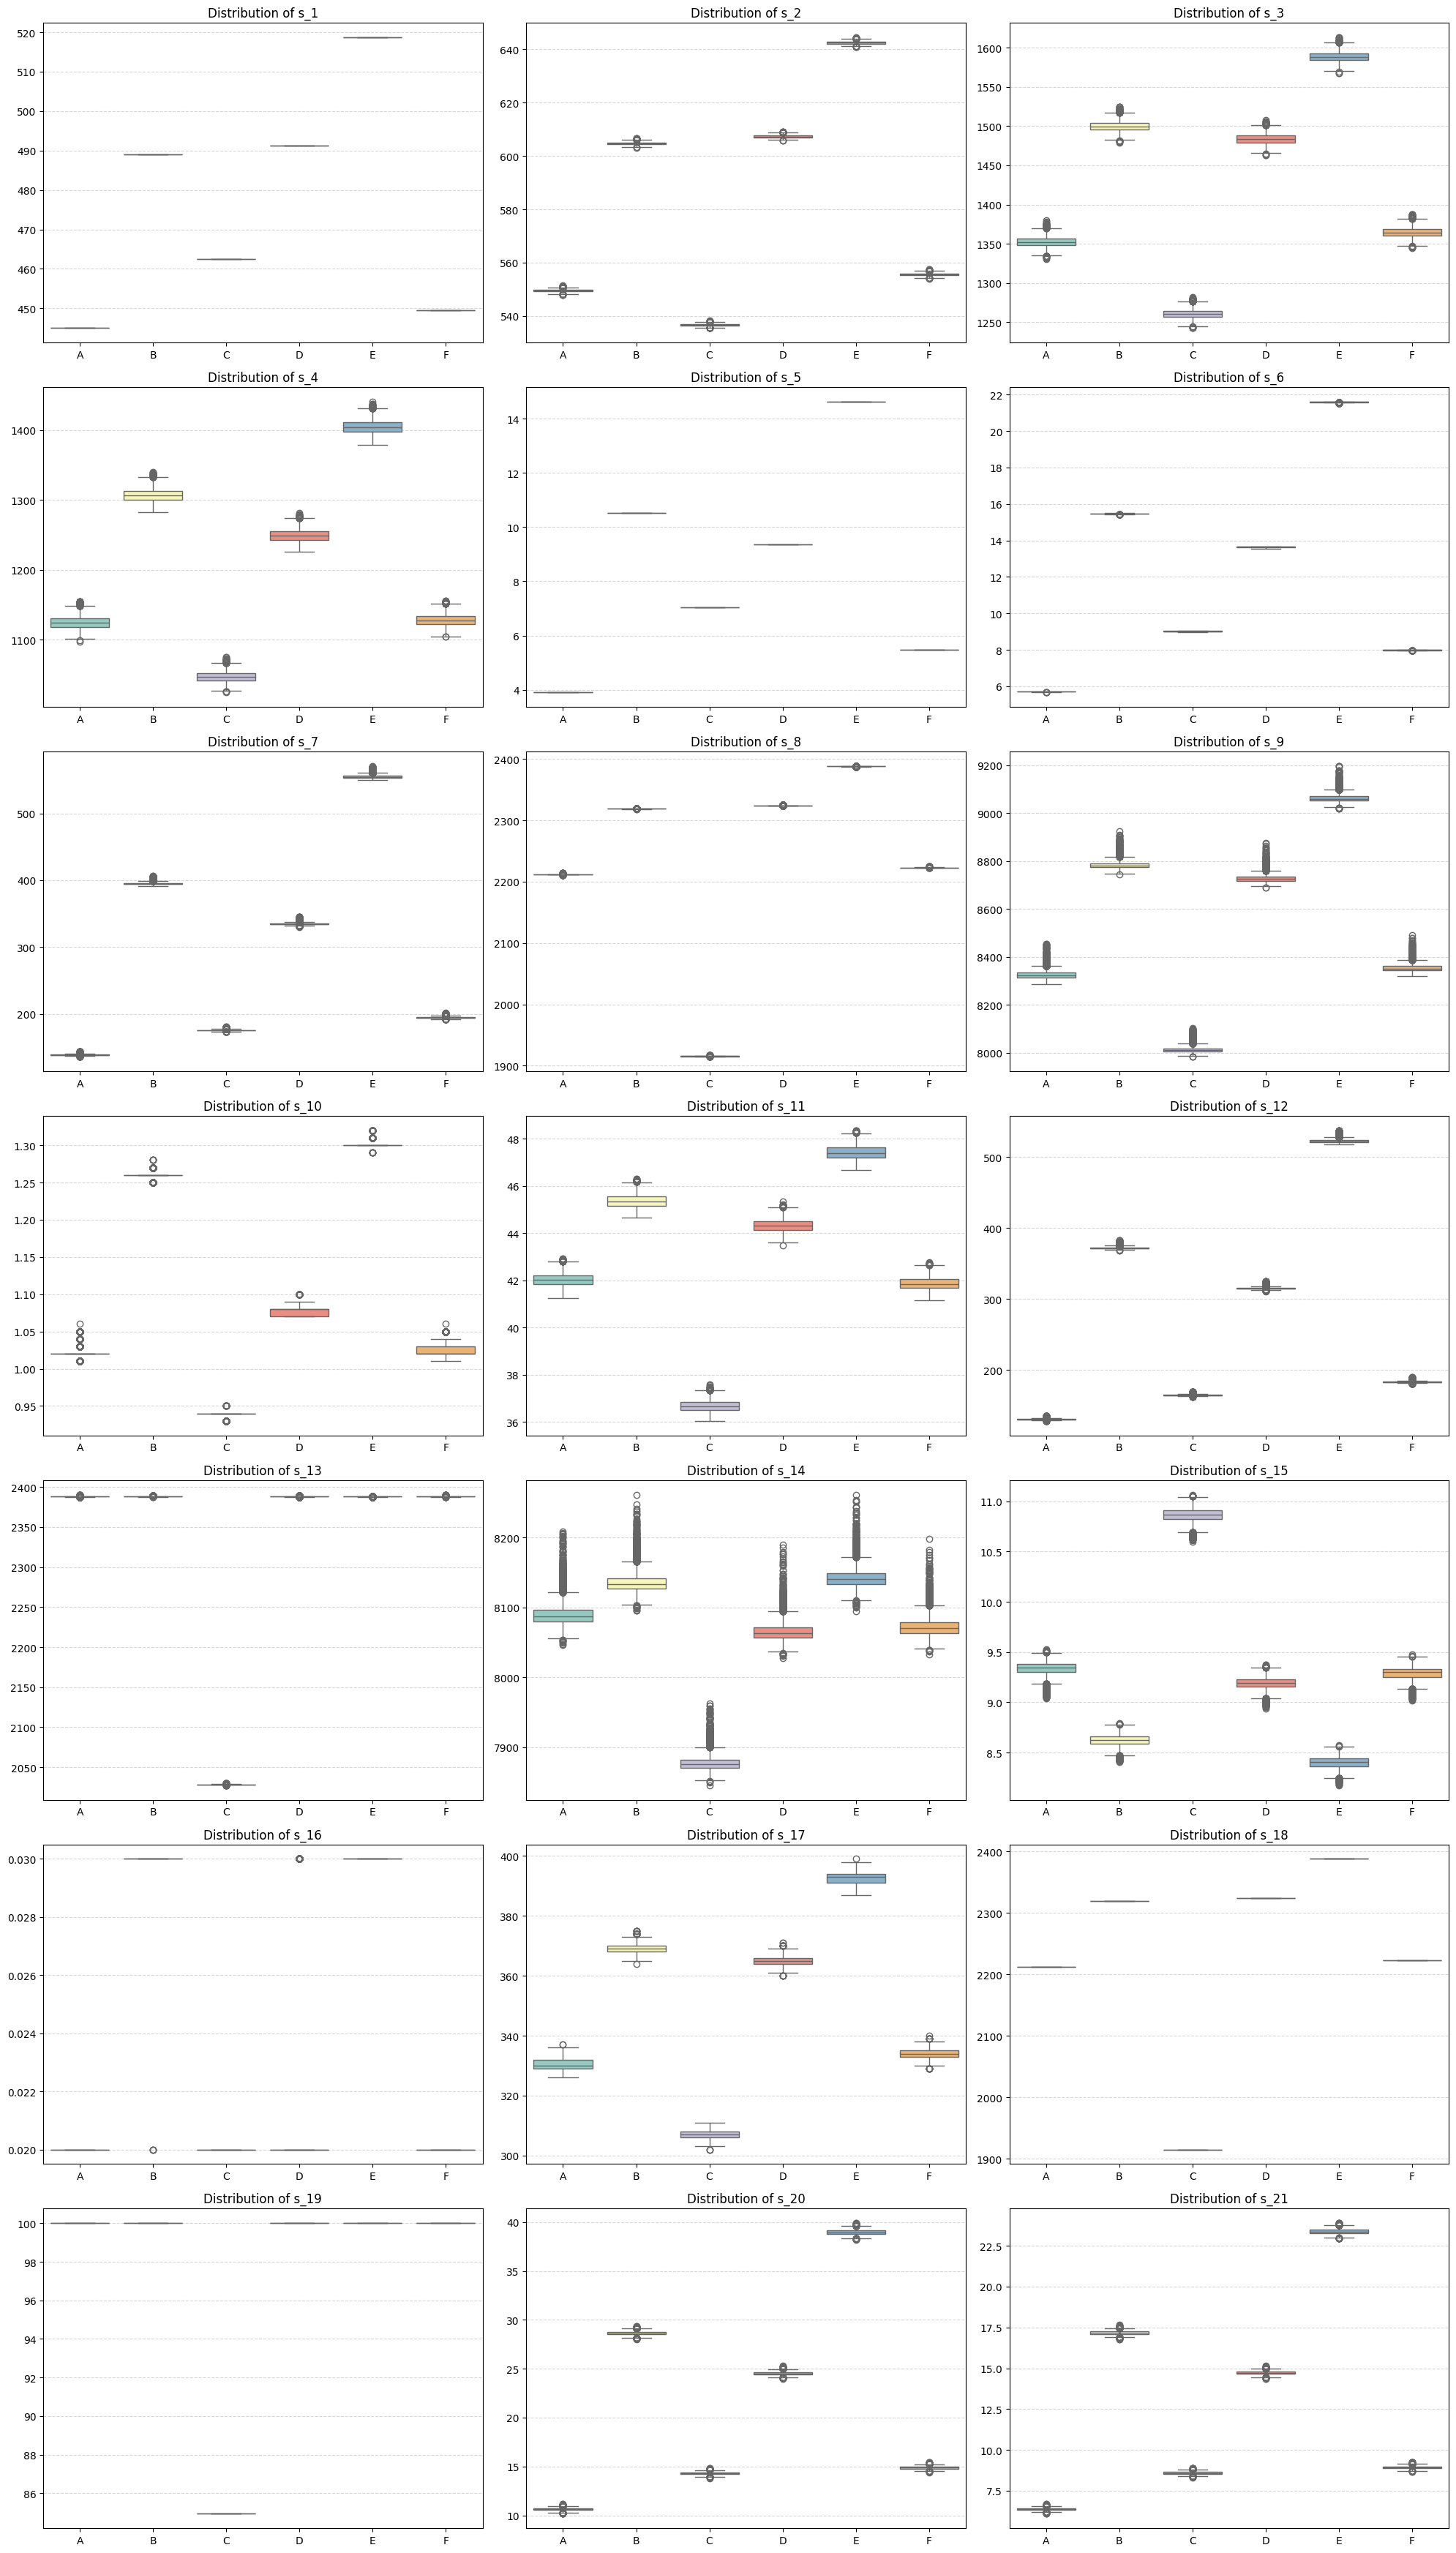

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 센서 컬럼 리스트 생성 (s_1 ~ s_21)
sensor_cols = [f's_{i}' for i in range(1, 22)]

# 7행 3열로 그래프 영역 생성
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(20, 35))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.boxplot(x='Cluster_Label', y=col, data=df, ax=axes[i], 
                order=['A', 'B', 'C', 'D', 'E', 'F'], palette='Set3')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

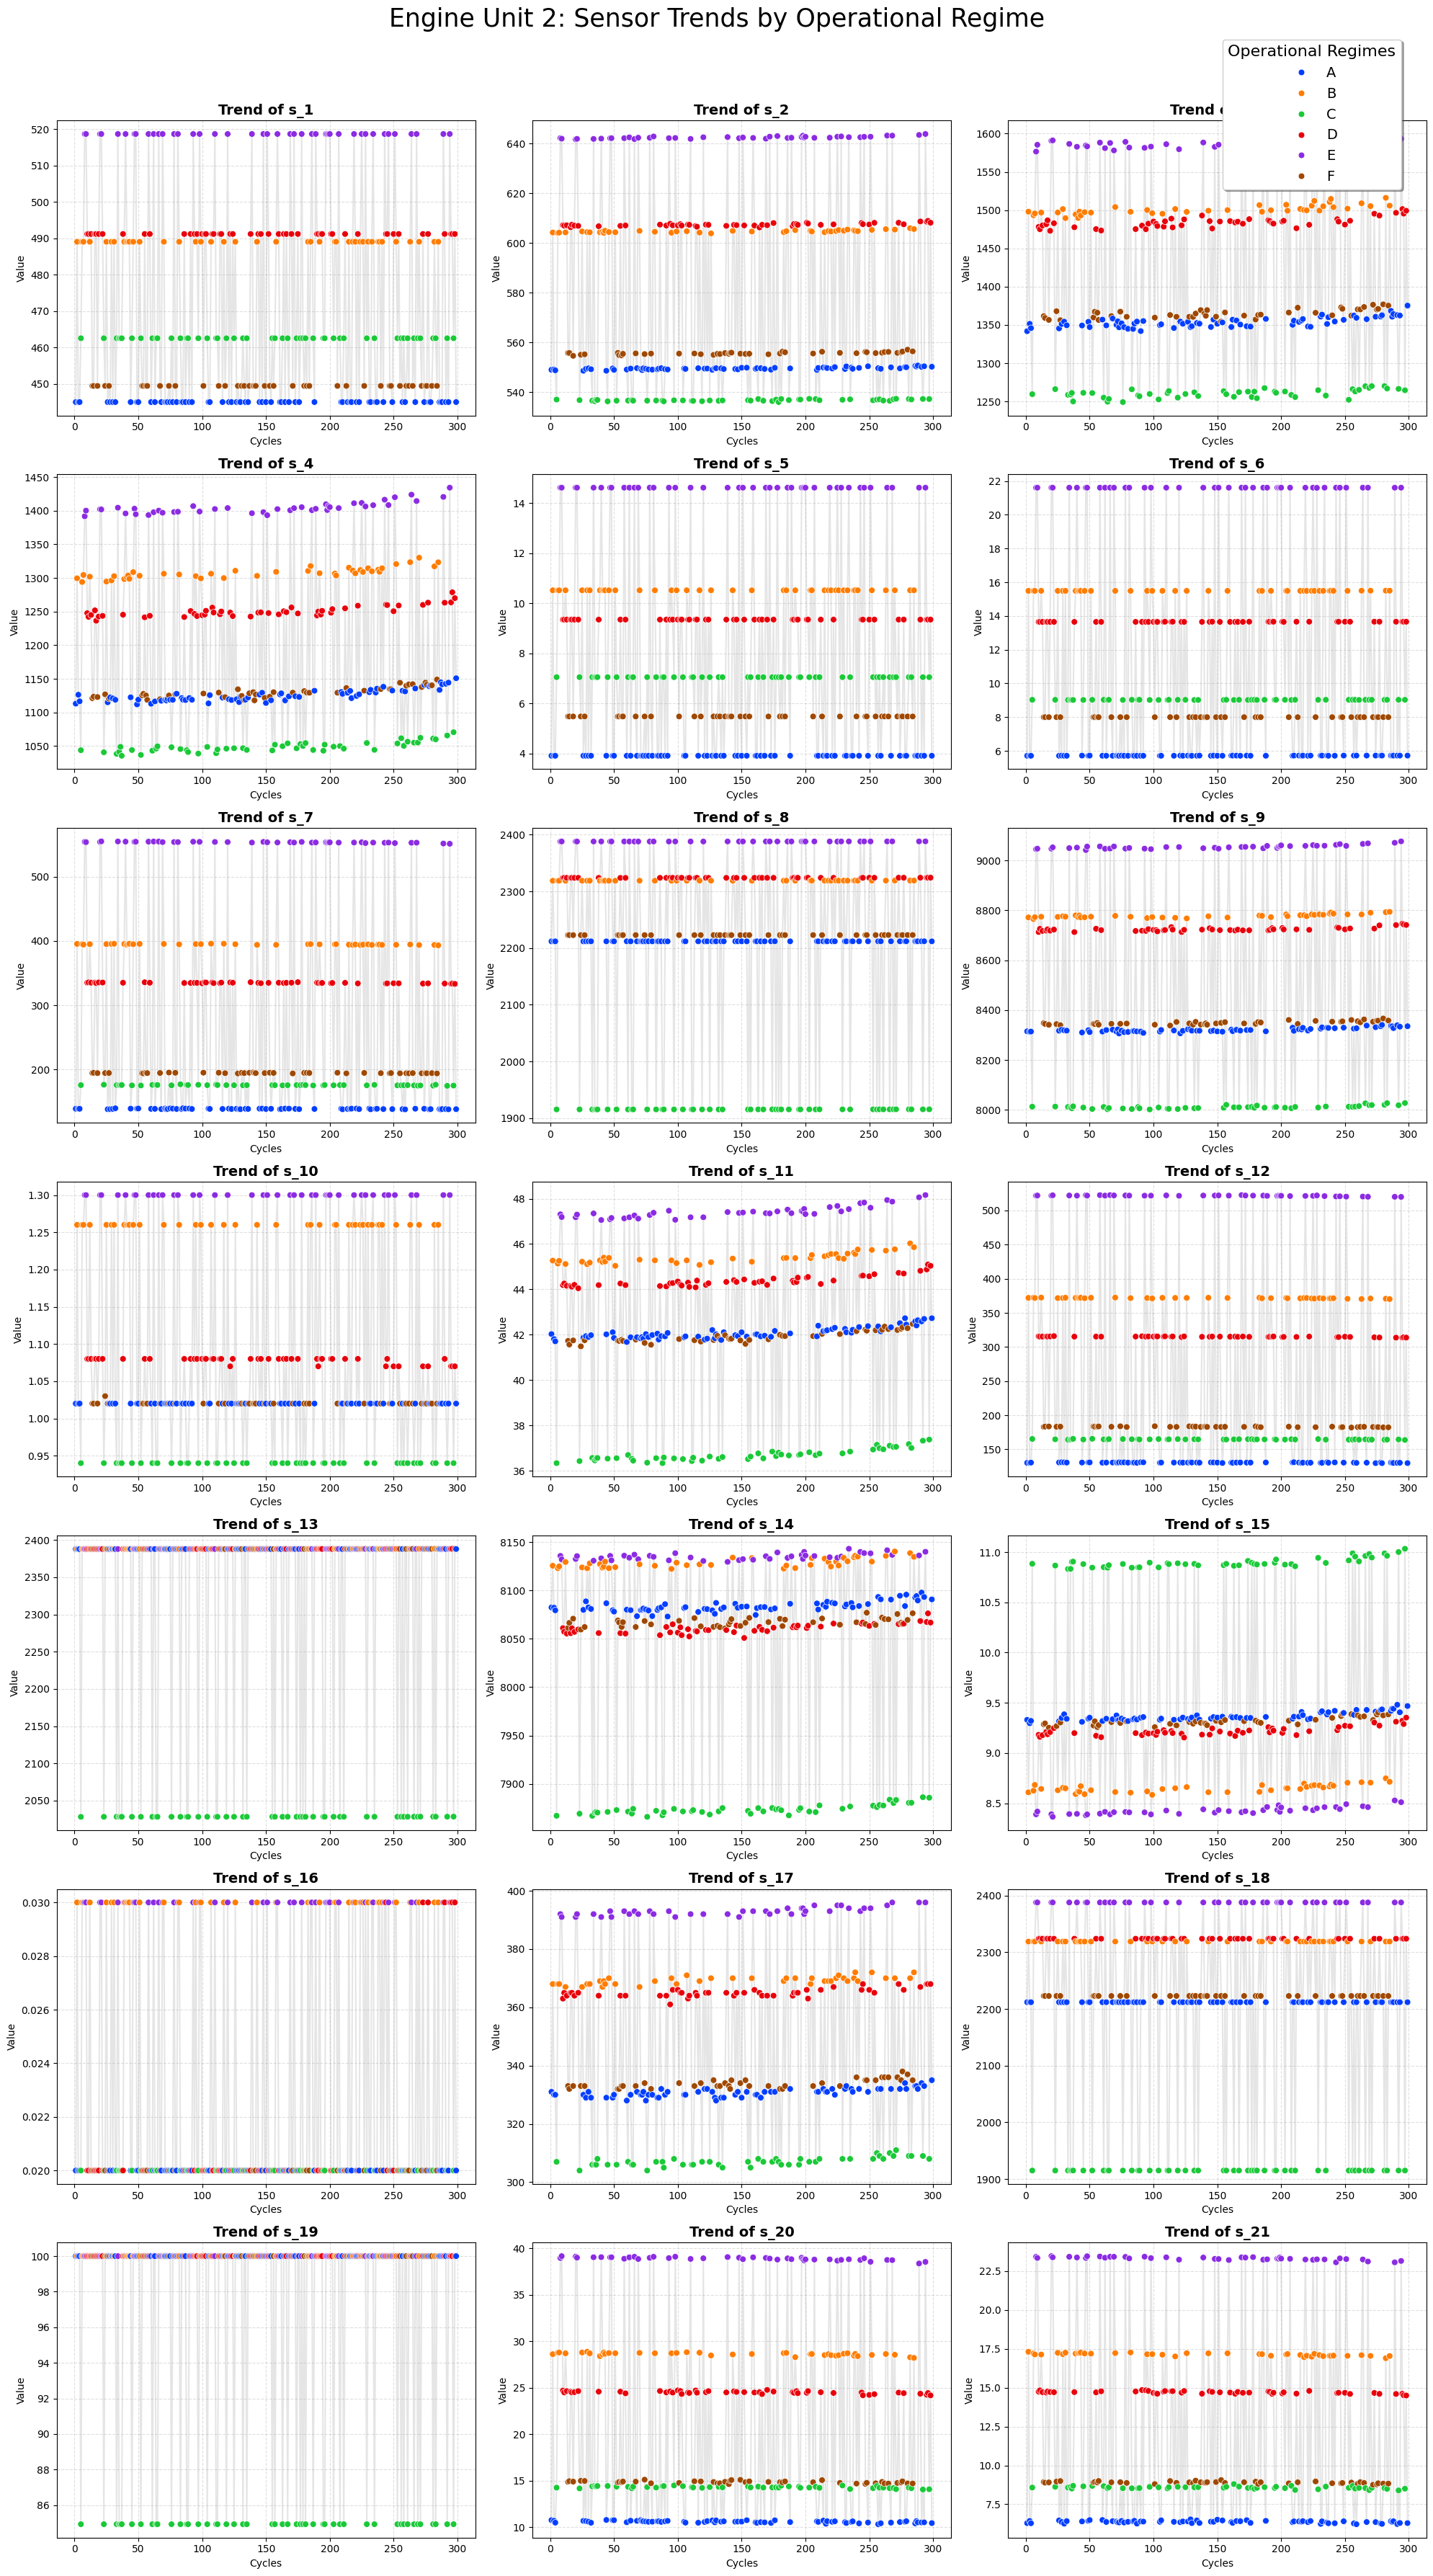

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화할 엔진 유닛 선택 (예: 1번 엔진)
unit_id = 2 
unit_data = df[df['unit_nr'] == unit_id].sort_values('time_cycles')

# 2. 센서 리스트 생성
sensor_cols = [f's_{i}' for i in range(1, 22)]

# 3. 그래프 설정 (7행 3열)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(20, 35))
fig.suptitle(f'Engine Unit {unit_id}: Sensor Trends by Operational Regime', fontsize=25, y=1.02)
axes = axes.flatten()

# 범례를 위한 색상 팔레트 고정 (A~F)
regime_order = ['A', 'B', 'C', 'D', 'E', 'F']
palette = sns.color_palette("bright", 6)

for i, col in enumerate(sensor_cols):
    # 흐릿한 배경 라인 (전체적인 변화 흐름 파악용)
    axes[i].plot(unit_data['time_cycles'], unit_data[col], color='gray', alpha=0.2, zorder=1)
    
    # 운행 조건별 색상 점 (Scatter)
    sns.scatterplot(
        data=unit_data, 
        x='time_cycles', 
        y=col, 
        hue='Cluster_Label', 
        hue_order=regime_order,
        palette=palette,
        ax=axes[i], 
        s=40, 
        edgecolor='w',
        linewidth=0.5,
        zorder=2
    )
    
    axes[i].set_title(f'Trend of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cycles')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.4)
    
    # 개별 그래프 내부의 범례는 가독성을 위해 제거
    if axes[i].get_legend():
        axes[i].get_legend().remove()

# 4. 전체 그래프 우측 상단에 통합 범례 추가
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 1.01), 
           title='Operational Regimes', title_fontsize=16, fontsize=14, shadow=True)

plt.tight_layout()
plt.show()

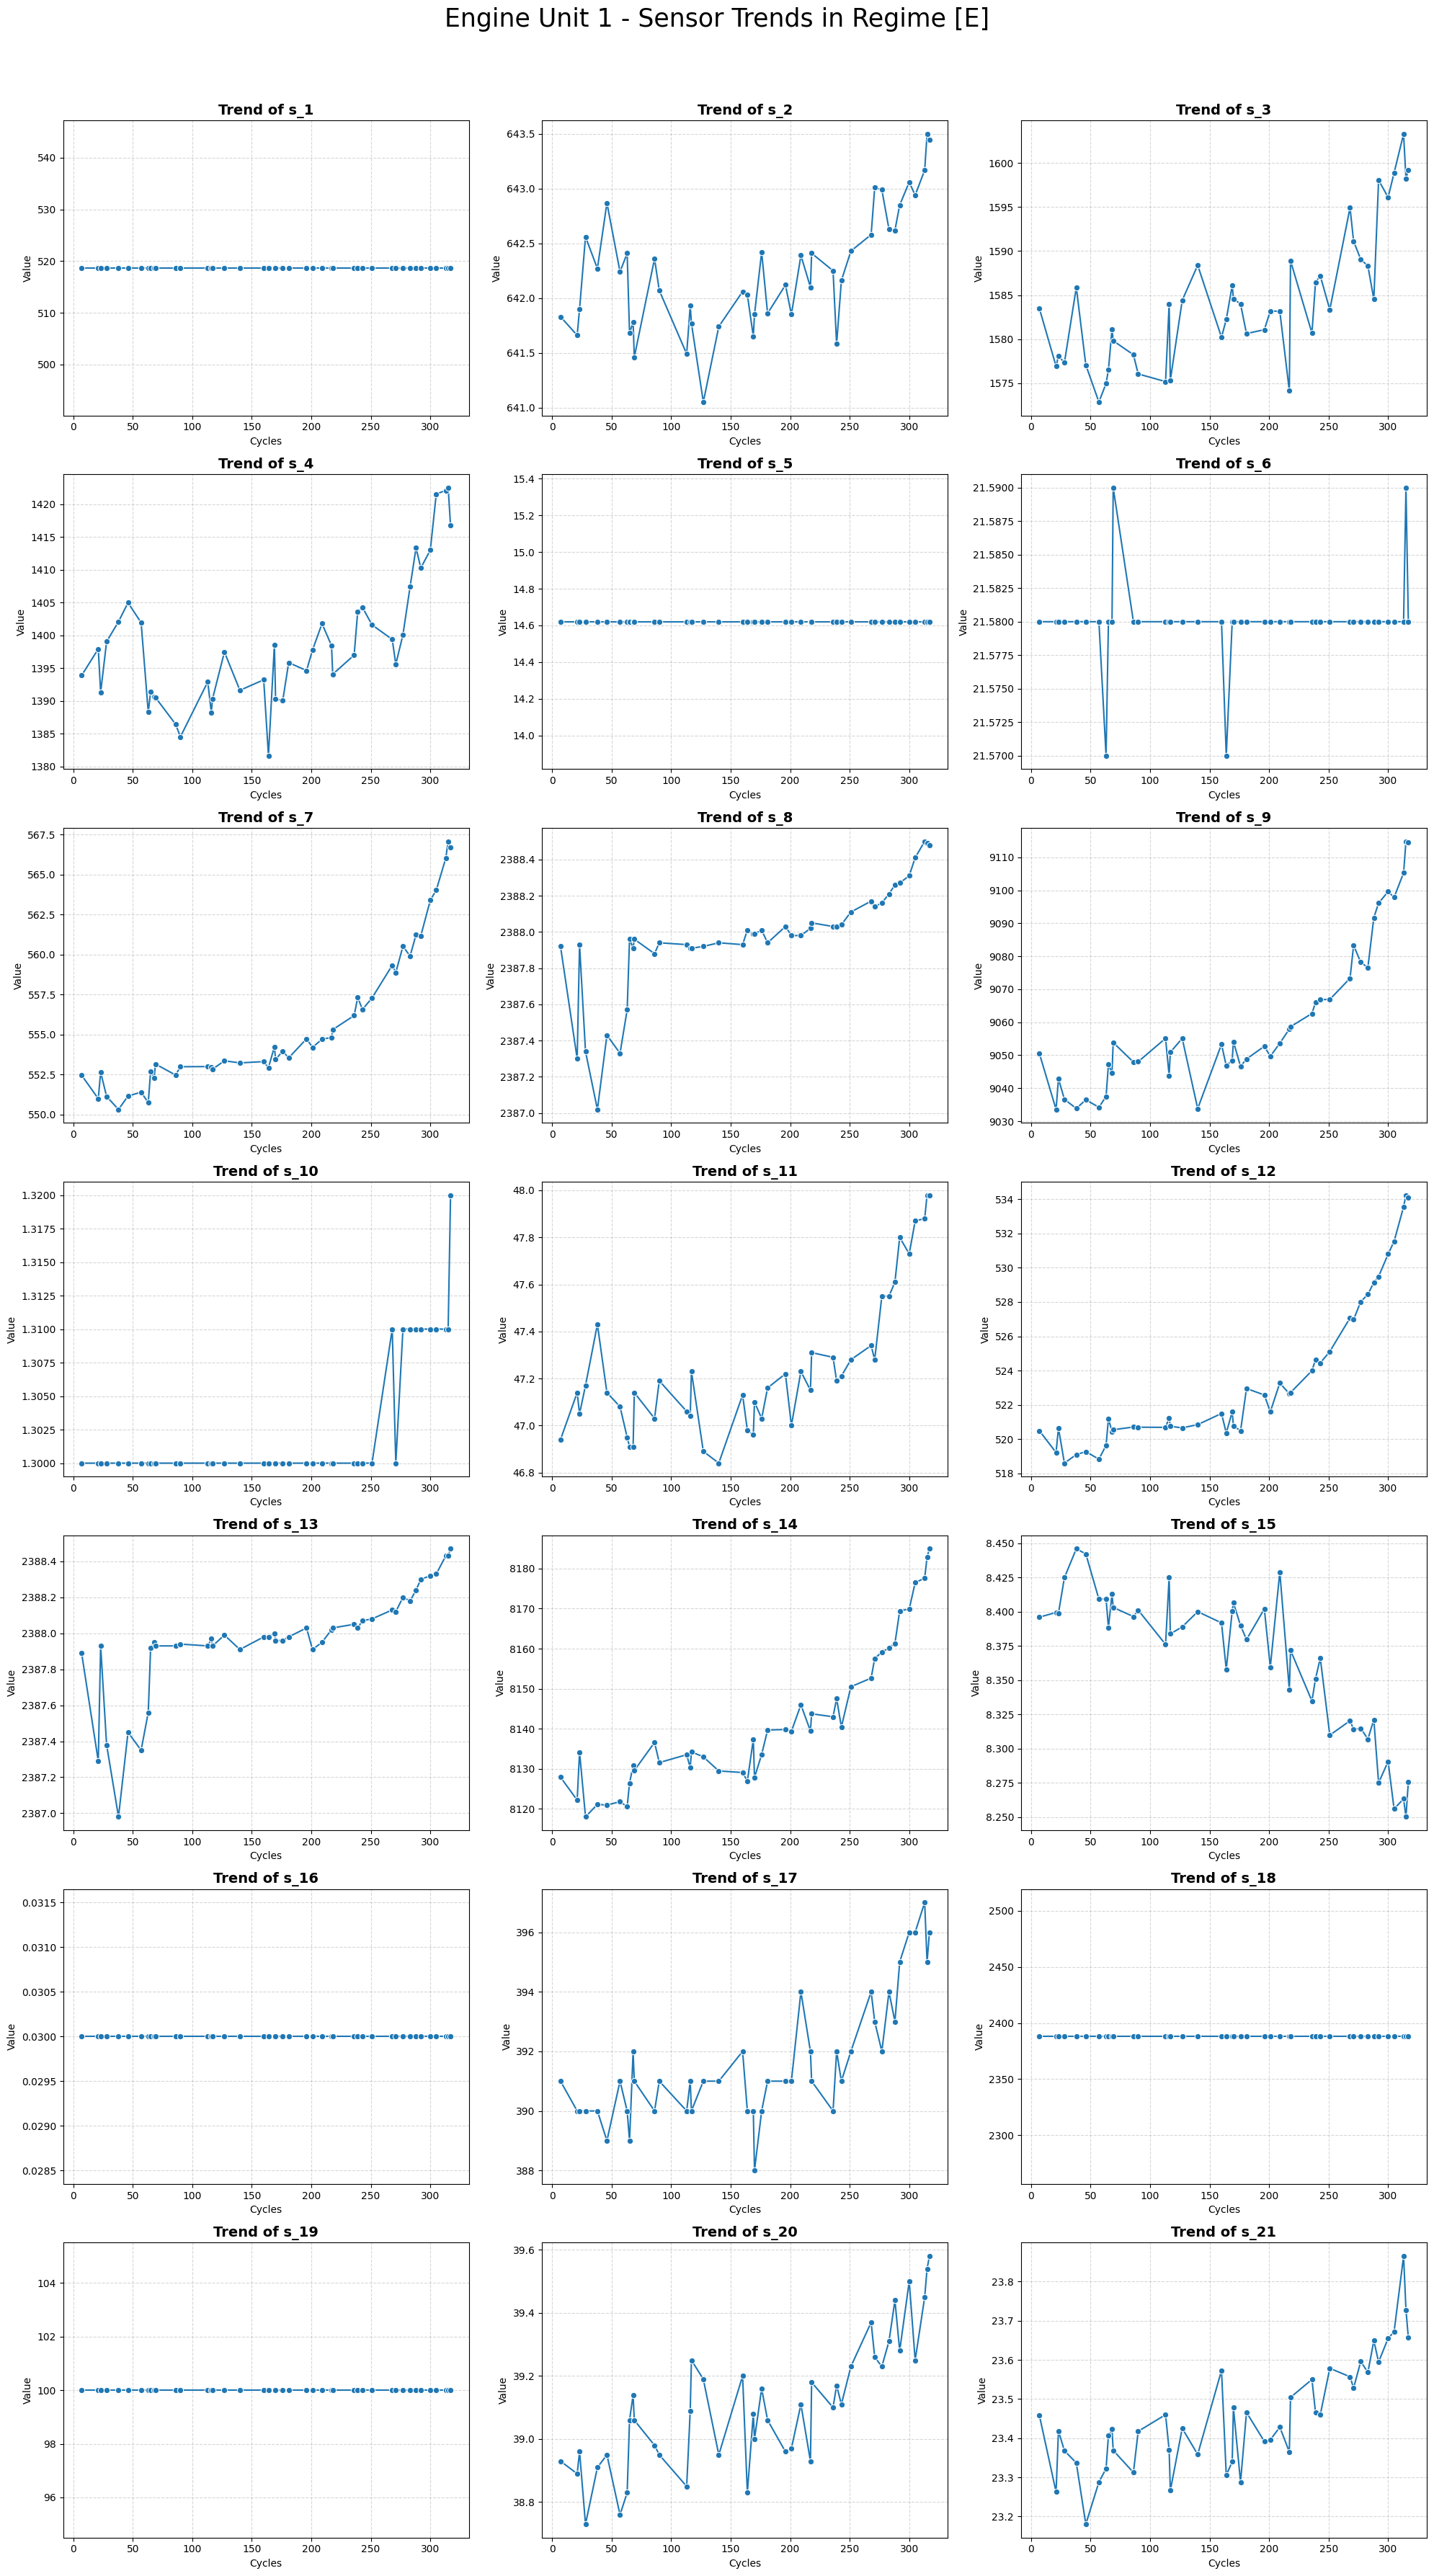

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분석할 엔진 번호와 운행 조건 선택
unit_id = 1       # 보고 싶은 엔진 번호
target_regime = 'E'  # 분석하고 싶은 운행 조건 (A, B, C, D, E, F 중 선택)

# 2. 데이터 필터링
# 선택한 엔진에서 특정 운행 조건 데이터만 추출
filtered_data = df[(df['unit_nr'] == unit_id) & (df['Cluster_Label'] == target_regime)].sort_values('time_cycles')

# 3. 시각화할 센서 리스트 (상수 센서 제외하고 주요 열화 센서 위주로 선택 가능)
sensor_cols = [f's_{i}' for i in range(1, 22)]

# 4. 그래프 그리기 (7행 3열)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(20, 35))
fig.suptitle(f'Engine Unit {unit_id} - Sensor Trends in Regime [{target_regime}]', fontsize=25, y=1.02)
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    # 라인 그래프 + 산점도
    sns.lineplot(data=filtered_data, x='time_cycles', y=col, ax=axes[i], marker='o', color='tab:blue')
    
    axes[i].set_title(f'Trend of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cycles')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

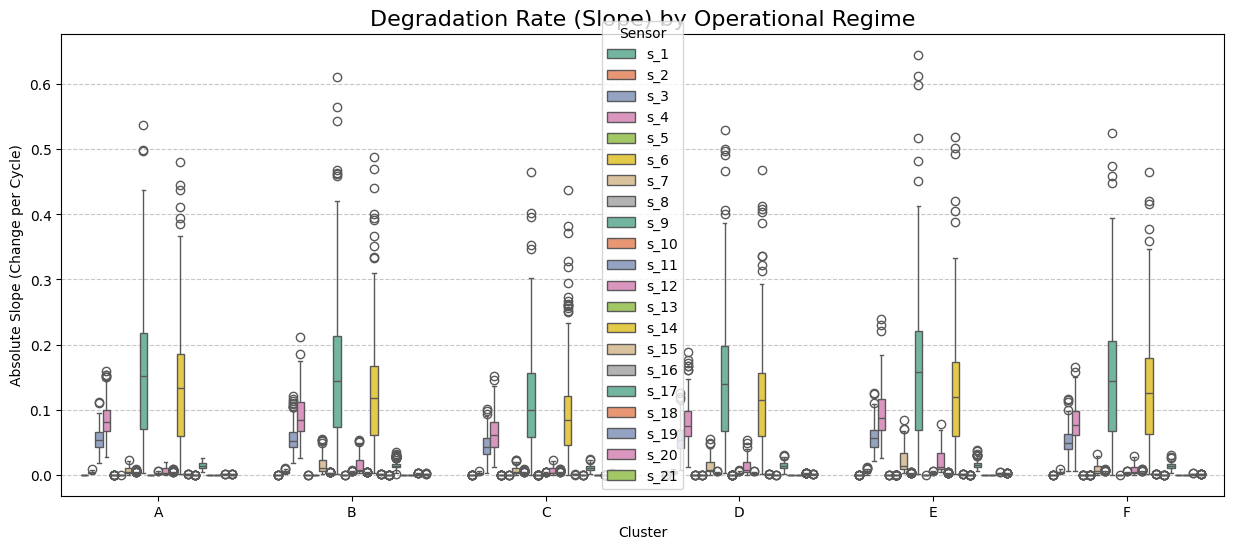

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. 분석할 주요 열화 센서 선택 (예: s_2, s_11, s_15)
target_sensors = [f's_{i}' for i in range(1, 22)]
results = []

# 2. 엔진별, 군집별로 루프를 돌며 기울기(변화량) 계산
for unit in df['unit_nr'].unique():
    unit_df = df[df['unit_nr'] == unit]
    for cluster in ['A', 'B', 'C', 'D', 'E', 'F']:
        cluster_df = unit_df[unit_df['Cluster_Label'] == cluster]
        
        # 데이터가 최소 3개 이상은 있어야 신뢰할 만한 기울기가 나옵니다.
        if len(cluster_df) > 5:
            for sensor in target_sensors:
                # 선형 회귀로 기울기 도출 (Cycle 대비 센서값)
                slope, _, _, _, _ = linregress(cluster_df['time_cycles'], cluster_df[sensor])
                results.append({'unit_nr': unit, 'Cluster': cluster, 'Sensor': sensor, 'Slope': abs(slope)})

slope_df = pd.DataFrame(results)

# 3. 시각화: 어떤 조건에서 변화량(Slope)이 가장 큰가?
plt.figure(figsize=(15, 6))
sns.boxplot(data=slope_df, x='Cluster', y='Slope', hue='Sensor', palette='Set2')
plt.title('Degradation Rate (Slope) by Operational Regime', fontsize=16)
plt.ylabel('Absolute Slope (Change per Cycle)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg

def analyze_sensor_mean_by_cluster(df, sensor_name):
    """
    원본 데이터(df)를 사용하여 특정 센서의 클러스터별 평균 차이를 검정합니다.
    """
    print(f"\n" + "="*80)
    print(f" 🚀 [{sensor_name}] 센서의 운행 조건별 '평균 센서량' 차이 검정")
    print("="*80)
    
    # 1. 데이터 준비 (원본 df 사용)
    # df에 'Cluster'와 해당 센서 컬럼이 반드시 있어야 합니다.
    data = df[['Cluster', sensor_name]].dropna()
    
    # 2. 정규성 검정
    print(f"\n[STEP 1] 정규성 검정 (Shapiro-Wilk)")
    try:
        normality_df = pg.normality(data=data, dv=sensor_name, group='Cluster')
        is_normal = normality_df['normal'].all()
        print(f"  ▶ 결과: {'정규성 만족' if is_normal else '정규성 위배 (데이터가 많으면 ANOVA 진행 가능)'}")
    except:
        print("  ▶ 결과: 데이터 크기 등으로 인해 정규성 검정 생략")

    # 3. 등분산성 검정
    print(f"\n[STEP 2] 등분산성 검정 (Levene)")
    levene_test = pg.homoscedasticity(data=data, dv=sensor_name, group='Cluster', method='levene')
    is_equal_var = levene_test.iloc[0, 0] 
    levene_p = levene_test.iloc[0, 1] 
    print(f"  ▶ 결과: {'등분산성 만족' if is_equal_var else '등분산성 위배'} (p: {levene_p:.5f})")

    # 4. ANOVA 검정 (가설 반영)
    print(f"\n[STEP 3] 집단 간 평균 차이 검정 (ANOVA)")
    print(f"  - 귀무가설(H0): 모든 그룹(Cluster)의 평균 센서량({sensor_name})은 같다.")
    print(f"  - 대립가설(H1): 적어도 하나의 그룹은 평균 센서량이 다르다.")

    if is_equal_var:
        print(f"  * 분석 경로: [One-way ANOVA] 수행")
        aov = pg.anova(dv=sensor_name, between='Cluster', data=data)
        posthoc_method = 'tukey'
    else:
        print(f"  * 분석 경로: [Welch's ANOVA] 수행")
        aov = pg.welch_anova(dv=sensor_name, between='Cluster', data=data)
        posthoc_method = 'gameshowell'

    # p-value 추출
    p_cols = [c for c in aov.columns if any(x in c.lower() for x in ['p-', 'p_val', 'pvalue', 'p-unc']) or c.lower() == 'p']
    anova_p = aov[p_cols[0]].values[0] if p_cols else aov.iloc[0, -1]

    print(f"  ▶ 최종 결과: {'유의미한 차이 발견 (H1 채택)' if anova_p < 0.05 else '평균 동일 (H0 채택)'} (p: {anova_p:.10f})")

    # 5. 사후 검정 (Post-hoc)
    if anova_p < 0.05:
        print(f"\n[STEP 4] 사후 검정 ({posthoc_method.upper()})")
        if posthoc_method == 'tukey':
            posthoc = pg.pairwise_tukey(dv=sensor_name, between='Cluster', data=data)
        else:
            posthoc = pg.pairwise_gameshowell(dv=sensor_name, between='Cluster', data=data)
        
        ph_p_cols = [c for c in posthoc.columns if any(x in c.lower() for x in ['p-', 'pvalue', 'p-adj']) or c.lower() == 'p']
        ph_p_col = ph_p_cols[0] if ph_p_cols else posthoc.columns[-1]
        
        significant = posthoc[posthoc[ph_p_col] < 0.05].copy()
        
        if not significant.empty:
            # 평균값 차이(diff)가 큰 순서대로 출력
            display_cols = [c for c in ['A', 'B', 'diff', ph_p_col] if c in posthoc.columns]
            print(significant[display_cols].sort_values(by='diff', ascending=False).to_string(index=False))
        else:
            print("  ▶ 유의미한 차이를 보이는 특정 그룹 쌍이 없습니다.")
    else:
        print("\n모든 클러스터에서 평균 센서량이 통계적으로 동일합니다.")

# --- 실행부 ---
# 원본 데이터셋 'df'를 직접 넣습니다.
analyze_sensor_mean_by_cluster(df, 's_8')


 🚀 [s_8] 센서의 운행 조건별 '평균 센서량' 차이 검정

[STEP 1] 정규성 검정 (Shapiro-Wilk)
  ▶ 결과: 정규성 위배 (데이터가 많으면 ANOVA 진행 가능)

[STEP 2] 등분산성 검정 (Levene)
  ▶ 결과: 등분산성 만족 (p: 0.00000)

[STEP 3] 집단 간 평균 차이 검정 (ANOVA)
  - 귀무가설(H0): 모든 그룹(Cluster)의 평균 센서량(s_8)은 같다.
  - 대립가설(H1): 적어도 하나의 그룹은 평균 센서량이 다르다.
  * 분석 경로: [One-way ANOVA] 수행
  ▶ 최종 결과: 평균 동일 (H0 채택) (p: 0.9999978568)

모든 클러스터에서 평균 센서량이 통계적으로 동일합니다.


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15395.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9091.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9139.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9162.
  res = hypotest_fun_out(*samples, **kwds)
c:\User

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
from sklearn.linear_model import LinearRegression

def analyze_trend_difference(df, sensor_name):
    """
    1. 엔진/클러스터별로 기울기(Slope)를 계산합니다.
    2. 계산된 기울기 값들로 클러스터 간 평균 차이(ANOVA)를 검정합니다.
    """
    print(f"\n" + "="*80)
    print(f" 🚀 [{sensor_name}] 센서의 클러스터별 '추세(Slope)' 차이 검정 시작")
    print("="*80)

    # --- STEP 1: 엔진/클러스터별 기울기(Slope) 추출 ---
    slopes = []
    # 각 엔진(unit)과 클러스터 조합별로 반복
    for (unit, cluster), group in df.groupby(['unit_nr', 'Cluster_Label']):
        if len(group) < 2: continue  # 데이터가 2개 미만이면 기울기 계산 불가
        
        # 선형 회귀로 기울기 계산
        X = group['time_cycles'].values.reshape(-1, 1)
        y = group[sensor_name].values
        model = LinearRegression().fit(X, y)
        
        slopes.append({
            'unit_NR': unit,
            'Cluster_Label': cluster,
            'Slope_Value': model.coef_[0]  # 이것이 바로 '변화율'
        })
    
    slope_df_local = pd.DataFrame(slopes)

    # --- STEP 2: 가설 설정 및 통계 분석 ---
    print(f"\n[분석 대상] 각 조건별 {sensor_name}의 시간 대비 변화량(기울기)")
    print(f"  - 귀무가설(H0): 모든 클러스터 그룹의 평균 센서량 변화(Slope)는 같다.")
    print(f"  - 대립가설(H1): 적어도 하나의 그룹은 평균 센서량 변화(Slope)가 다르다.")

    # 등분산성 확인 (Levene)
    levene_test = pg.homoscedasticity(data=slope_df_local, dv='Slope_Value', group='Cluster_Label')
    is_equal_var = levene_test.iloc[0, 0]

    # ANOVA 수행
    if is_equal_var:
        print(f"\n  ▶ 등분산 만족: One-way ANOVA 수행")
        aov = pg.anova(dv='Slope_Value', between='Cluster_Label', data=slope_df_local)
        posthoc_method = 'tukey'
    else:
        print(f"\n  ▶ 등분산 위배: Welch's ANOVA 수행")
        aov = pg.welch_anova(dv='Slope_Value', between='Cluster_Label', data=slope_df_local)
        posthoc_method = 'gameshowell'

    # p-value 추출
    p_cols = [c for c in aov.columns if any(x in c.lower() for x in ['p-', 'p_val', 'pvalue', 'p-unc']) or c.lower() == 'p']
    anova_p = aov[p_cols[0]].values[0] if p_cols else aov.iloc[0, -1]

    print(f"  ▶ ANOVA 결과 p-value: {anova_p:.10f}")

    # --- STEP 3: 사후 검정 (어떤 클러스터가 특히 다른가?) ---
    if anova_p < 0.05:
        print(f"\n[STEP 4] 사후 검정 결과 ({posthoc_method.upper()})")
        if posthoc_method == 'tukey':
            posthoc = pg.pairwise_tukey(dv='Slope_Value', between='Cluster_Label', data=slope_df_local)
        else:
            posthoc = pg.pairwise_gameshowell(dv='Slope_Value', between='Cluster_Label', data=slope_df_local)
        
        ph_p_cols = [c for c in posthoc.columns if any(x in c.lower() for x in ['p-', 'pvalue', 'p-adj']) or c.lower() == 'p']
        ph_p_col = ph_p_cols[0] if ph_p_cols else posthoc.columns[-1]
        
        significant = posthoc[posthoc[ph_p_col] < 0.05].copy()
        if not significant.empty:
            display_cols = [c for c in ['A', 'B', 'diff', ph_p_col] if c in posthoc.columns]
            print(significant[display_cols].sort_values(by='diff', ascending=False).to_string(index=False))
            print(f"\n💡 해석: diff가 (+)로 크면 A 조건이 B보다 센서량이 더 가파르게 증가함을 의미합니다.")
        else:
            print("  ▶ 유의미한 추세 차이를 보이는 특정 그룹 쌍이 없습니다.")
    else:
        print("\n결과: 모든 클러스터의 센서 추세가 통계적으로 유사합니다.")

# --- 실행부 ---
# s_8, s_13 등 방향성이 의심되는 센서들을 넣어보세요.
analyze_trend_difference(df, 's_2')
analyze_trend_difference(df, 's_15')


 🚀 [s_2] 센서의 클러스터별 '추세(Slope)' 차이 검정 시작

[분석 대상] 각 조건별 s_2의 시간 대비 변화량(기울기)
  - 귀무가설(H0): 모든 클러스터 그룹의 평균 센서량 변화(Slope)는 같다.
  - 대립가설(H1): 적어도 하나의 그룹은 평균 센서량 변화(Slope)가 다르다.

  ▶ 등분산 만족: One-way ANOVA 수행
  ▶ ANOVA 결과 p-value: 0.1481142762

결과: 모든 클러스터의 센서 추세가 통계적으로 유사합니다.

 🚀 [s_15] 센서의 클러스터별 '추세(Slope)' 차이 검정 시작

[분석 대상] 각 조건별 s_15의 시간 대비 변화량(기울기)
  - 귀무가설(H0): 모든 클러스터 그룹의 평균 센서량 변화(Slope)는 같다.
  - 대립가설(H1): 적어도 하나의 그룹은 평균 센서량 변화(Slope)가 다르다.

  ▶ 등분산 만족: One-way ANOVA 수행
  ▶ ANOVA 결과 p-value: 0.0079916612

[STEP 4] 사후 검정 결과 (TUKEY)
A B          diff    hedges
B D  2.320479e-05  0.049282
D E -7.090542e-07 -0.001518
B C -1.494294e-05 -0.029888
A F -5.338605e-05 -0.097595
A D -9.700448e-05 -0.185566
A E -9.771353e-05 -0.194617
A B -1.202093e-04 -0.237795
A C -1.351522e-04 -0.246129

💡 해석: diff가 (+)로 크면 A 조건이 B보다 센서량이 더 가파르게 증가함을 의미합니다.
